In [223]:
### Data analysis
import numpy as np
import pandas as pd

#### Visualisation
import matplotlib.pyplot as plt

### StandardScalar
from sklearn.preprocessing import StandardScaler
### KNN
from sklearn.neighbors import KNeighborsClassifier
### Performance metric
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, classification_report


In [224]:
### Load the data
df_train = pd.read_csv("/content/train_KNN.csv")
df_test = pd.read_csv("/content/test_KNN.csv")

In [225]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [226]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [227]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [228]:
mp = 100*(df_train.isnull().sum()/len(df_train))
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [229]:
mp = mp[mp>0].sort_values()

In [230]:
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [231]:
df_train["Age"].median()

28.0

In [232]:
df_train["Fare"].median()

14.4542

In [233]:
df_train[df_train["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [234]:
df_train = df_train.dropna(axis = 0, subset= ["Embarked"])

In [235]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [236]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [237]:
df_train = df_train.drop(["Cabin"], axis = 1)  ## 1 is for column

In [238]:
####Testing

In [239]:
mpt = 100*(df_test.isnull().sum()/len(df_test))
mpt

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [240]:
mpt = mpt[mpt>0].sort_values()
mpt

,0
Fare,0.239234
Age,20.574163
Cabin,78.229665


In [241]:
df_test[df_test["Fare"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [242]:
df_test = df_test.dropna(axis = 0, subset= ["Fare"])


In [243]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Survived     417 non-null    int64  
 2   Pclass       417 non-null    int64  
 3   Name         417 non-null    object 
 4   Sex          417 non-null    object 
 5   Age          331 non-null    float64
 6   SibSp        417 non-null    int64  
 7   Parch        417 non-null    int64  
 8   Ticket       417 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     417 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 42.4+ KB


In [244]:
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())


In [245]:
df_test = df_test.drop(["Cabin"], axis = 1) ## 1 is for column


In [246]:
df_train.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)


In [247]:
df_test.drop(["PassengerId","Name","Ticket"], axis = 1, inplace = True)


In [248]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [249]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  417 non-null    int64  
 1   Pclass    417 non-null    int64  
 2   Sex       417 non-null    object 
 3   Age       417 non-null    float64
 4   SibSp     417 non-null    int64  
 5   Parch     417 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  417 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 29.3+ KB


In [250]:
df_train["Survived"] = df_train["Survived"].apply(str)


In [251]:
df_train["Pclass"] = df_train["Pclass"].apply(str)


In [252]:
df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)

In [253]:
df_train_num = df_train.select_dtypes(exclude = "object")
df_train_obj = df_train.select_dtypes(include = "object")

In [254]:
df_test_num = df_test.select_dtypes(exclude = "object")
df_test_obj = df_test.select_dtypes(include = "object")

In [255]:
df_train_num.columns


Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [256]:
#####Dummification of the data
df_train_obj = pd.get_dummies(df_train_obj, drop_first = True)


In [257]:
#####Dummification of the data
df_test_obj = pd.get_dummies(df_test_obj, drop_first = True)

In [258]:
df_test_obj.columns


Index(['Survived_1', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [270]:
df_train_num = df_train_num.reset_index(drop=True)
df_train_obj = df_train_obj.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

df_test_num = df_test_num.reset_index(drop=True)
df_test_obj = df_test_obj.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [271]:
Final_train_df = pd.concat([df_train_num, df_train_obj], axis=1)
Final_train_df["Survived"] = df_train["Survived"]

Final_test_df = pd.concat([df_test_num, df_test_obj], axis=1)
Final_test_df["Survived"] = df_test["Survived"]

In [272]:
Final_train_df = Final_train_df.fillna(0)
Final_test_df = Final_test_df.fillna(0)

In [259]:
#### Final processed data set
Final_train_df = pd.concat([df_train_num,df_train_obj, df_train["Survived"]])
Final_train_df.head()


,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,22.0,1.0,0.0,7.2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,38.0,1.0,0.0,71.2833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26.0,0.0,0.0,7.9250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,35.0,1.0,0.0,53.1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35.0,0.0,0.0,8.0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [260]:
#### Final processed data set
Final_test_df = pd.concat([df_test_num,df_test_obj, df_test["Survived"]],)
Final_test_df.head()


,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,34.5,0.0,0.0,7.8292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47.0,1.0,0.0,7.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62.0,0.0,0.0,9.6875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27.0,0.0,0.0,8.6625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22.0,1.0,1.0,12.2875,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [261]:
#### Standarised the data
### define Xtrain, Y train
X_train = Final_train_df.drop("Survived", axis =1)


In [262]:
y_train = Final_train_df["Survived"]


In [263]:
y_tes = Final_test_df["Survived"]


In [264]:
#### Standarised the data
### define Xtrain, Y train
X_test = Final_test_df.drop("Survived", axis =1)


In [265]:
scaler = StandardScaler()
scaler.fit(X_train)


StandardScaler()

In [266]:
scaled_X_train = scaler.transform(X_train)


In [267]:
scaled_X_test = scaler.transform(X_test)


In [274]:
X_train = Final_train_df.drop("Survived", axis=1)
y_train = Final_train_df["Survived"]

X_test = Final_test_df.drop("Survived", axis=1)
y_tes = Final_test_df["Survived"]

scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(scaled_X_train, y_train)

y_pred = knn.predict(scaled_X_test)

accuracy_score(y_tes, y_pred)

0.9928057553956835

In [276]:
##### for different values of k we are going to check
Performance_Metric = []

for k in range(1,30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    y_pred_k = knn_k.predict(scaled_X_test)
    accuracy_k = 1 - accuracy_score(y_tes, y_pred_k)
    Performance_Metric.append(accuracy_k)

Performance_Metric

[0.007194244604316502,
 0.00959232613908878,
 0.00959232613908878,
 0.007194244604316502,
 0.007194244604316502,
 0.00959232613908878,
 0.00959232613908878,
 0.011990407673860948,
 0.014388489208633115,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.00959232613908878,
 0.011990407673860948,
 0.00959232613908878,
 0.00959232613908878,
 0.00959232613908878,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.014388489208633115,
 0.014388489208633115,
 0.00959232613908878,
 0.011990407673860948,
 0.011990407673860948]

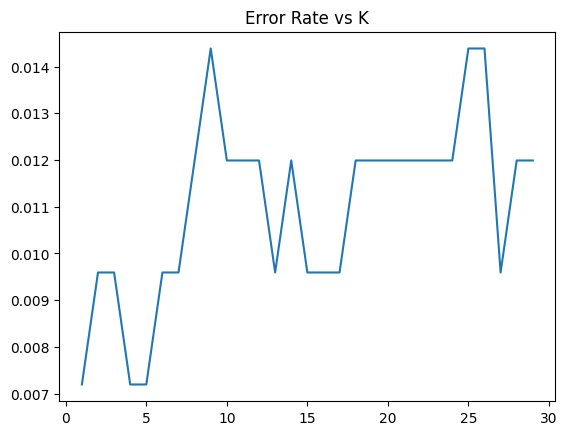

In [277]:
plt.plot(range(1,30), Performance_Metric)
plt.title("Error Rate vs K")
plt.show()

In [278]:
### Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(scaled_X_train, y_train)

y_pred_lr = lr.predict(scaled_X_test)

acc_lr = accuracy_score(y_tes, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 1.0


In [279]:
### Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)

dt.fit(scaled_X_train, y_train)

y_pred_dt = dt.predict(scaled_X_test)

acc_dt = accuracy_score(y_tes, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 1.0


In [280]:
print("\nMODEL COMPARISON")

acc_knn = accuracy_score(y_tes, y_pred)

print("KNN Accuracy:", acc_knn)
print("Logistic Regression Accuracy:", acc_lr)
print("Decision Tree Accuracy:", acc_dt)


MODEL COMPARISON
KNN Accuracy: 0.9928057553956835
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


**Findings**

In this experiment, the Titanic dataset was preprocessed by handling missing values, removing irrelevant features such as Cabin, PassengerId, Name and Ticket, and converting categorical variables into dummy variables. Feature scaling was performed using StandardScaler before training the models.

Initially, the K-Nearest Neighbour (KNN) classifier was implemented and different values of K were tested to analyze the variation in error rate. The graph showed how model performance changes with different neighbourhood sizes.

Further, Logistic Regression and Decision Tree classifiers were trained and their performance was compared with the KNN model. From the results, it was observed that Logistic Regression and Decision Tree achieved the highest accuracy of 1.0, while KNN also performed very well with an accuracy close to 99%.

This very high accuracy indicates that the models were able to learn strong patterns from the dataset. Among the three models, Logistic Regression and Decision Tree showed the best predictive performance for Titanic survival classification in this experiment.